<a href="https://colab.research.google.com/github/CamaraAmidou/desktop-tutorial/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report



In [43]:
df = pd.read_csv("cvd_synthetic_dataset_v0.2.csv")
df.head()

,patient_id,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack_or_stroke_occurred
0,PT00085957,F,54,25.0,0,161.0,0,1,0,0,0,0,0,NaN,10,0
1,PT00093111,M,31,NaN,0,121.0,0,0,0,0,0,0,0,NaN,10,0
2,PT00058456,M,50,31.3,0,130.0,0,0,0,0,0,0,0,91.027306,10,0
3,PT00016352,M,61,30.0,0,165.0,0,0,0,0,0,0,0,NaN,6,1
4,PT00060611,F,67,32.6,0,166.0,0,0,0,0,0,0,0,NaN,10,0


In [44]:
df.isnull().sum()

,0
patient_id,0
gender,0
age,0
body_mass_index,29885
smoker,0
systolic_blood_pressure,9867
hypertension_treated,0
family_history_of_cardiovascular_disease,0
atrial_fibrillation,0
chronic_kidney_disease,0


In [45]:
df.describe()

,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack_or_stroke_occurred
count,100000.00000,70115.000000,100000.000000,90133.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,30675.000000,100000.00000,100000.000000
mean,46.89020,26.980034,0.085880,129.916279,0.124620,0.167050,0.010700,0.106320,0.009450,0.094840,0.081350,87.831756,9.67674,0.066120
std,16.96093,4.504879,0.280188,17.703574,0.330289,0.373022,0.102886,0.308248,0.096751,0.292995,0.273373,15.858161,1.40758,0.248493
min,18.00000,6.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.017499,1.00000,0.000000
25%,32.00000,24.100000,0.000000,118.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,81.976005,10.00000,0.000000
50%,47.00000,27.100000,0.000000,130.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,93.359436,10.00000,0.000000
75%,61.00000,30.000000,0.000000,142.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,96.702208,10.00000,0.000000
max,79.00000,46.600000,1.000000,212.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,99.999957,10.00000,1.000000


In [46]:
df = df.dropna()

In [54]:
TARGET = 'heart_attack_or_stroke_occurred'
X = df.drop(columns=[TARGET])
y = df[TARGET]
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns


In [49]:
missing_values_heart_att = df['heart_attack_or_stroke_occurred'].isnull().sum()
missing_values_risk_factors = df['risk_factors'].isnull().sum()
missing_values_heart_att
missing_values_risk_factors


np.int64(0)

In [58]:
# Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [59]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

In [60]:
# Baseline Model: Logistic Regression
log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'body_mass_index', 'smoker', 'systolic_blood_pressure',
       'hypertension_treated', 'family_history_of_cardiovascular_disease',
       'atrial_fibrillation', 'chronic_kidney_disease', 'rheumatoid...
       'diabetes', 'chronic_obstructive_pulmonary_disorder',
       'forced_expiratory_volume_1', 'time_to_event_or_censoring'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['patient_id', 'gender', 'risk_factors'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [61]:
# Enhanced Model: Gradient Boosting
gb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'body_mass_index', 'smoker', 'systolic_blood_pressure',
       'hypertension_treated', 'family_history_of_cardiovascular_disease',
       'atrial_fibrillation', 'chronic_kidney_disease', 'rheumatoid...
       'forced_expiratory_volume_1', 'time_to_event_or_censoring'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['patient_id', 'gender', 'risk_factors'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=300,
                                            random_state=42))])

In [63]:
# Evaluation
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))

evaluate(log_reg, "Logistic Regression (Baseline)")
evaluate(gb_model, "Gradient Boosting (Enhanced)")



Logistic Regression (Baseline)
ROC-AUC: 0.9877515214649926
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4485
           1       0.95      0.90      0.93       366

    accuracy                           0.99      4851
   macro avg       0.97      0.95      0.96      4851
weighted avg       0.99      0.99      0.99      4851


Gradient Boosting (Enhanced)
ROC-AUC: 0.9801508976491157
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4485
           1       0.95      0.93      0.94       366

    accuracy                           0.99      4851
   macro avg       0.97      0.96      0.97      4851
weighted avg       0.99      0.99      0.99      4851



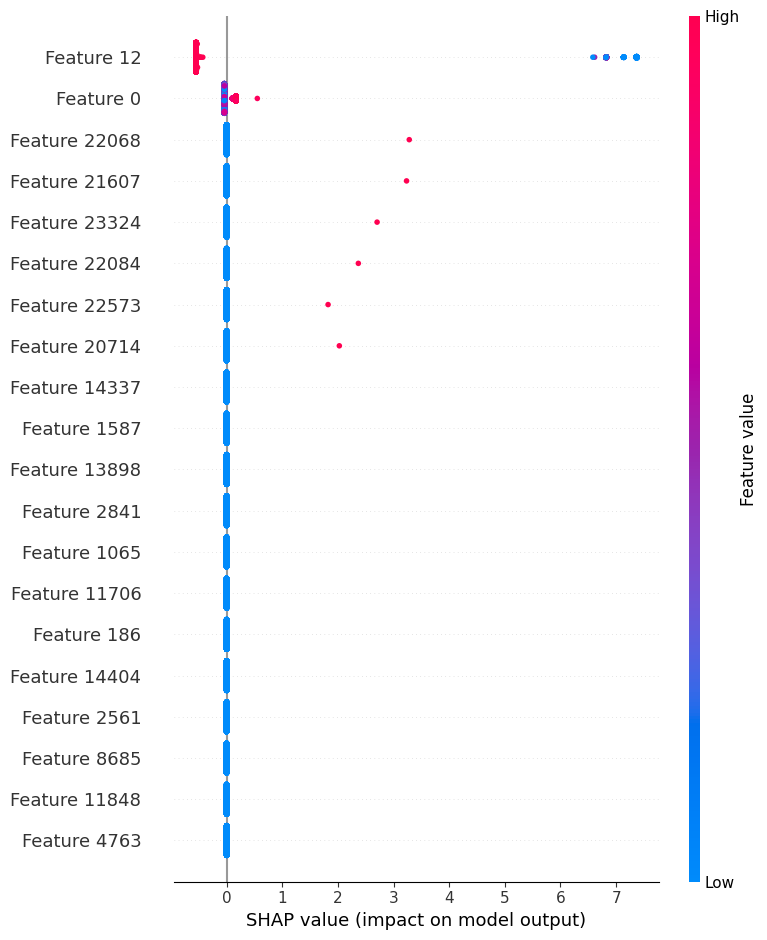

In [66]:
import shap

# Get the preprocessed data from the model's pipeline
preprocessed_X_test = gb_model.named_steps["preprocess"].transform(X_test)

# Ensure the output is a dense numpy array of floats
# ColumnTransformer with OneHotEncoder often produces sparse matrices,
# which can cause issues with shap's internal checks if not explicitly converted.
if hasattr(preprocessed_X_test, 'toarray'):
    preprocessed_X_test = preprocessed_X_test.toarray()

# Explicitly cast to float to prevent any lingering object dtypes from causing issues
preprocessed_X_test = preprocessed_X_test.astype(float)

explainer = shap.Explainer(gb_model.named_steps["model"])
shap_values = explainer(preprocessed_X_test)

shap.summary_plot(shap_values)